# Objective: Analyse data on GDP and life expectancy from the World Health Organization and the World Bank to try to identify the relationship between the GDP and life expectancy of six countries.

## Task 0: Load the necessary libraries.

In [73]:
# To load data
import pandas as pd

In [74]:
# To display the line of best fit equation
import scipy.stats as ss

In [75]:
# To create visualisations
import matplotlib.pyplot as plt
import seaborn as sns

## Task 1: Load the data.

In [76]:
gdp_and_life_expectancy = pd.read_csv('all_data.csv')
print('Here\'s a preview of the GDP-life expectancy dataset:')
print(gdp_and_life_expectancy.head())

Here's a preview of the GDP-life expectancy dataset:
  Country  Year  Life expectancy at birth (years)       GDP ($)  \
0   Chile  2000                              77.3  7.790000e+10   
1   Chile  2001                              77.3  7.100000e+10   
2   Chile  2002                              77.8  6.970000e+10   
3   Chile  2003                              77.9  7.560000e+10   
4   Chile  2004                              78.0  9.920000e+10   

   GDP ($ billion)  
0            77.86  
1            70.98  
2            69.74  
3            75.64  
4            99.21  


## Task 2: Perform a preliminary exploration and explanation of the data.

### Summary statistics: life expectancy

In [77]:
print('Here\'s a summary of each country\'s life expectancy data:')
print(gdp_and_life_expectancy.groupby('Country')['Life expectancy at birth (years)'].describe())

Here's a summary of each country's life expectancy data:
                          count      mean       std   min     25%    50%  \
Country                                                                    
Chile                      16.0  78.94375  1.058911  77.3  77.975  79.00   
China                      16.0  74.26250  1.318016  71.7  73.400  74.45   
Germany                    16.0  79.65625  0.975000  78.0  78.950  79.85   
Mexico                     16.0  75.71875  0.620987  74.8  75.225  75.65   
United States of America   16.0  78.06250  0.832566  76.8  77.425  78.15   
Zimbabwe                   16.0  50.09375  5.940311  44.3  45.175  47.40   

                             75%   max  
Country                                 
Chile                     79.825  80.5  
China                     75.250  76.1  
Germany                   80.525  81.0  
Mexico                    76.150  76.7  
United States of America  78.725  79.3  
Zimbabwe                  55.325  60.7  


**Observations**
* Zimbabwe has not only the lowest mean life expectancy (50.09 years) but also the highest variation in age (a standard deviation of 5.94 years).
* Conversely, Germany has both the highest mean (79.65 years) and maximum (81.0 years) life expectancies.
* Life expectancy is the least varied in Mexico (a standard deviation of 0.62 years), suggesting life expectancies have not changed much there throughout the years.

### Summary statistics: GDP

In [78]:
print('Here\'s a summary of each country\'s GDP data (in billions of dollars):')
print(gdp_and_life_expectancy.groupby('Country')['GDP ($ billion)'].describe())

Here's a summary of each country's GDP data (in billions of dollars):
                          count          mean          std       min  \
Country                                                                
Chile                      16.0    169.789375    76.878265     69.74   
China                      16.0   4957.713750  3501.095795   1211.35   
Germany                    16.0   3094.775625   667.486248   1949.95   
Mexico                     16.0    976.650625   209.571821    683.65   
United States of America   16.0  14075.000000  2432.693980  10300.00   
Zimbabwe                   16.0      9.062500     4.296778      4.42   

                                 25%        50%         75%       max  
Country                                                                
Chile                        93.8725    173.000    244.9525    278.38  
China                      1881.5850   4075.195   7819.5500  11064.70  
Germany                    2740.8700   3396.350   3596.0775   389

**Observations**
* The United States is the richest nation regarding mean (\\$14.075 trillion) and maximum (\\$18.1 trillion) GDP. Zimbabwe, on the other hand, is the poorest nation in these regards (a mean of \\$9.0625 billion and a ceiling of \\$16.30 billion).
* China possesses the highest GDP variation (a standard deviation of \\$3.5 trillion), implying the nation's GDP has changed the most throughout the years.

## Task 3: Visualise the data using ...

### Univariate analysis

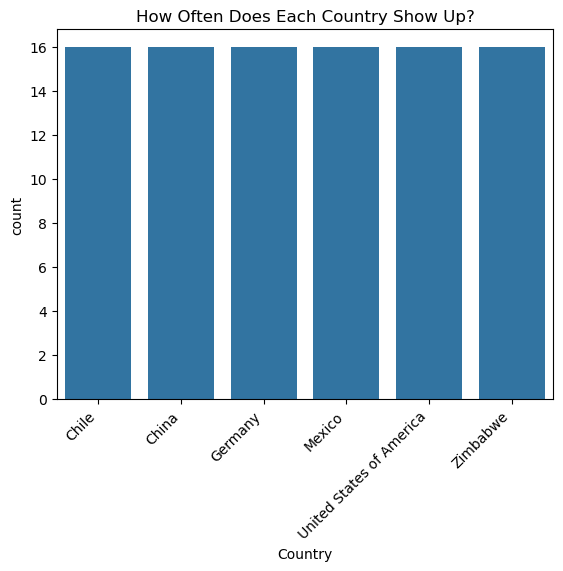

In [87]:
# A bar chart for country counts
sns.countplot(data=gdp_and_life_expectancy, x='Country')
plt.title('How Often Does Each Country Show Up?')
plt.xticks(rotation=45, ha='right')
plt.savefig('country_appearance.jpg')
plt.show()

**Observations:**
* All countries were counted the same number of times (16). This means the dataset contains one annual life expectancy and GDP record per country between 2000 and 2015.

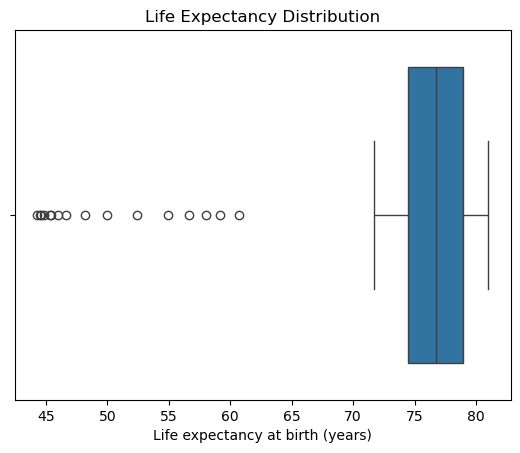

In [80]:
# A boxplot for life expectancy
sns.boxplot(data=gdp_and_life_expectancy, x='Life expectancy at birth (years)')
plt.title('Life Expectancy Distribution')
plt.savefig('life_expectancy_boxplot.png')
plt.show()

**Observations**
* Most of the dataset's life expectancies are between 70 and 80. As for the outliers, they are consistent with Zimbabwe's life expectancies.
* There is a large gap between 65 and 70 years, suggesting no country has recorded life expectancies in that range.

### Bivariate analysis

In [81]:
def strength_of_relationship(r, x, y):
    if (0.6<=abs(r)<=1.0):
        return f'{x} and {y} share a strong relationship.'
    elif (0.4<=abs(r)<0.6):
        return f'{x} and {y} share a moderate relationship.'
    elif (0<=abs(r)<0.4):
        return f'{x} and {y} share a weak relationship.'

GDP and life expectancy at birth share a strong relationship.


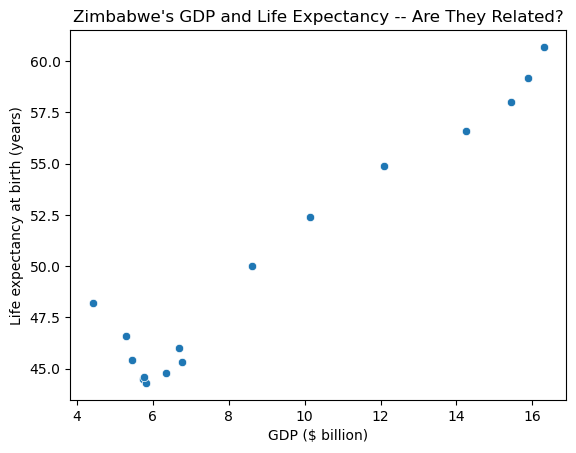

In [82]:
# Is Zimbabwe's GDP related to its life expectancy?
zimbabwe_data = gdp_and_life_expectancy[gdp_and_life_expectancy.Country=='Zimbabwe']
sns.scatterplot(data=zimbabwe_data, x='GDP ($ billion)', y='Life expectancy at birth (years)')
rho, p_value = ss.pearsonr(zimbabwe_data['GDP ($ billion)'], zimbabwe_data['Life expectancy at birth (years)'])
print(strength_of_relationship(rho, 'GDP', 'life expectancy at birth'))
plt.title('Zimbabwe\'s GDP and Life Expectancy -- Are They Related?')
plt.savefig('gdp_life_expectancy_in_zimbabwe.png')
plt.show()

**Observations**
* There is a strong positive relationship between GDP and life expectancy in Zimbabwe -- as GDP increases there, so does life expectancy.
* However, this should be interpreted as simple correlation rather than proof that GDP growth affects life expectancy.

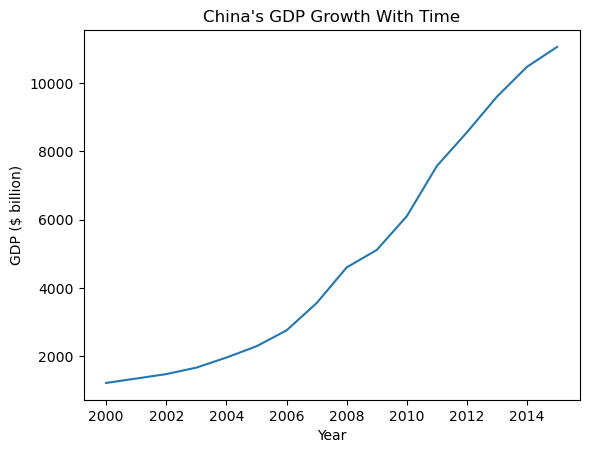

In [83]:
# How did China's GDP change throughout the years?
china_data = gdp_and_life_expectancy[gdp_and_life_expectancy.Country=='China']
sns.lineplot(data=china_data, x='Year', y='GDP ($ billion)')
plt.title('China\'s GDP Growth With Time')
plt.savefig('gdp_in_china.png')
plt.show()

**Observations**
* China's GDP growth was gradual in the early 2000's, then it accelerated towards the end of the decade.  

### Multivariate analysis

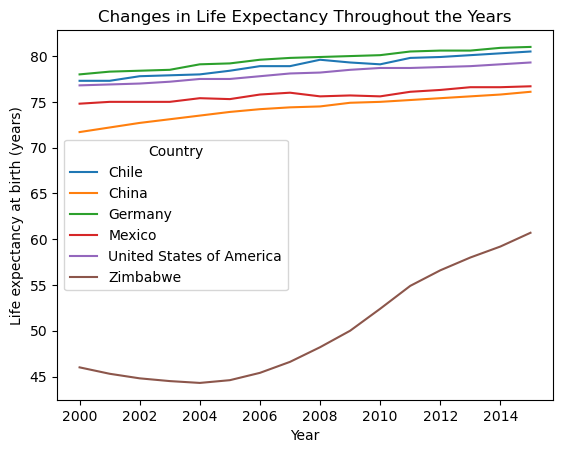

In [84]:
sns.lineplot(data=gdp_and_life_expectancy, x='Year', y='Life expectancy at birth (years)', hue='Country')
plt.title('Changes in Life Expectancy Throughout the Years')
plt.savefig('life_expectancy_changes.png')
plt.show()

**Observations**
* In every country, life expectancy generally increases with time.
* Zimbabwe's life expectancy, besides being the lowest in the dataset, appears parabolic. Between 2000 and 2004 it decreased, then it accelerated.

## Task 4: Conclusions

**What did you learn throughout the process?**
* I have learned from the above analysis that life expectancy and GDP have both increased with time. This suggests these variables are usually positively correlated, even though there is no concrete evidence that a nation's wealth causes longer lifespans.
* In addition, summary statistics are useful if one needs to compare unique values (e.g. median, maximum/minimum, mean) across categories. However, they are not useful in demonstrating how life expectancy and GDP change over time, much less if they're related in any capacity. As such, it is necessary to visualise this data.

**Are the results what you expected?**
* I had expected Zimbabwe, a Third World country, to have both the lowest GDP and life expectancy. Seeing as China is a growing world power, I also rightly expected its GDP to experience growth (as evidenced by the line graph and standard deviation above).
* I had not expected GDP and life expectancy to not always be related. For example, while the United States has the highest GDP on average, it does not boast the highest life expectancy -- that honour goes to Germany at 80.1 years.

**What are the key findings and takeaways?**
* Perhaps the most salient takeaway is that life expectancy is determined by more than GDP. Chile and Germany may not be as wealthy as the United States, but Chileans and Germans probably live longer due to social, healthcare, political, and environmental factors that Americans lack. Furthermore, while China's GDP has increased dramatically, life expectancy there did not change as much as Zimbabwe's.
* A key finding that is almost as important is that, in datasets like this, trends over time matter. For example, Zimbabwe's variation in life expectancy would be a mystery if the information had not been tabulated annually.